# Sales Performance Analysis and Prediction for Zudio Retail Stores

### import libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import zscore
import warnings
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from category_encoders import TargetEncoder
from sklearn.model_selection import learning_curve

###  Suppress warnings for both sklearn and lightgbm

In [34]:
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

### Data Loading and Initial Exploration

In [35]:
print("\U0001F4C8 Sales Performance Analysis and Prediction for Zudio Retail Stores \U0001F4C8")
print()

# Load the dataset
df = pd.read_csv("C:\\Users\\Administrator\\Desktop\\PDS\\Project\\Zudio_sales_data.csv")

# Number of rows and columns
print("✅Number of rows:", df.shape[0])
print("✅Number of columns:", df.shape[1])

# Column names
print("\n✅Column names:")
print(df.columns.tolist())

# Missing values
print("\n✅Missing values in each column:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

# Check for NaN in Sales Profit specifically
print("\n✅Missing values in 'Sales Profit':", df['Sales Profit'].isnull().sum())
print(f"✅ noteworthy rows with non-finite 'Sales Profit' in original dataset: {(~np.isfinite(df['Sales Profit'])).sum()}")

# Descriptive statistics
print("\n✅Descriptive statistics:")
print(df.describe())

# Dataset info
print("\n✅DataFrame info:")
print(df.info())

📈 Sales Performance Analysis and Prediction for Zudio Retail Stores 📈

✅Number of rows: 7899
✅Number of columns: 28

✅Column names:
['Store', 'Country', 'State', 'City', 'Category', 'Clothing Type', 'Store Number', 'Postal Code', 'Store Type', 'Store Open Date', 'Selling Area Size (sq ft)', 'Store Manager', 'Manager ID', 'Store Address', 'Contact Information', 'Operating Hours', 'Staff Count', 'Parking Availability', 'Security Features', 'Order ID', 'Order Date', 'Month', 'Customer ID', 'Customer Name', 'Product ID', 'Price', 'Quantity', 'Sales Profit']

✅Missing values in each column:
Security Features    2038
dtype: int64

✅Missing values in 'Sales Profit': 0
✅ noteworthy rows with non-finite 'Sales Profit' in original dataset: 0

✅Descriptive statistics:
       Store Number    Postal Code  Selling Area Size (sq ft)  Staff Count  \
count   7899.000000    7899.000000                7899.000000  7899.000000   
mean      50.666034  419982.374984                1112.077478    11.504747  

###  Data Cleaning and Preprocessing

In [26]:
# Make a copy
df_cleaned = df.copy()

# Convert "None" strings to actual missing values (np.nan)
df_cleaned.replace("None", np.nan, inplace=True)

# Convert date columns to datetime format
df_cleaned['Store Open Date'] = pd.to_datetime(df_cleaned['Store Open Date'], errors='coerce')
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], errors='coerce')

# Check and remove duplicate rows
duplicates = df_cleaned.duplicated().sum()
print(f"\nNumber of Duplicate Rows Removed: {duplicates}")
df_cleaned.drop_duplicates(inplace=True)

# Identify categorical columns
cat_cols = df_cleaned.select_dtypes(include='object').columns

# Fill missing values in categorical columns with mode
print("\nMissing Value Imputation Details:")
for col in cat_cols:
    if df_cleaned[col].isnull().sum() > 0:
        mode_value = df_cleaned[col].mode()[0]
        print(f"→ Column '{col}' had {df_cleaned[col].isnull().sum()} missing values. Filled with mode: '{mode_value}'")
        df_cleaned[col] = df_cleaned[col].fillna(mode_value)

# Final check for missing values
print("\nMissing Values After Cleaning:")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

# Show final dataset shape
print("\nCleaned Dataset Shape:", df_cleaned.shape)

# Save the cleaned dataset
output_path = "C:\\Users\\Administrator\\Desktop\\PDS\\Project\\Zudio_sales_data_cleaned.csv"
df_cleaned.to_csv(output_path, index=False)
print(f"\n✅ Cleaned file saved successfully at: {output_path}")


Number of Duplicate Rows Removed: 0

Missing Value Imputation Details:
→ Column 'Security Features' had 2038 missing values. Filled with mode: 'CCTV, Alarm'

Missing Values After Cleaning:
Series([], dtype: int64)

Cleaned Dataset Shape: (7899, 28)

✅ Cleaned file saved successfully at: C:\Users\Administrator\Desktop\PDS\Project\Zudio_sales_data_cleaned.csv


### Outlier Detection and Removal

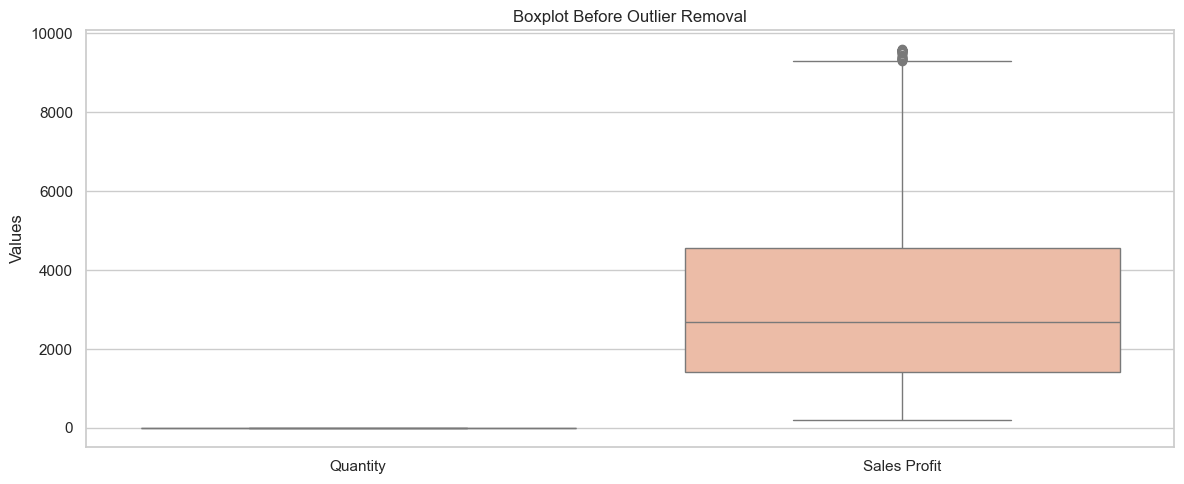


Processing outliers for 'Quantity'...
Column: 'Quantity' - No outliers detected.


Processing outliers for 'Sales Profit'...
Column: 'Sales Profit'
  Outliers detected: 29
  Value range for outliers: < -3327.60 or > 9309.20
  Min outlier value: 9312.0
  Max outlier value: 9596.8

Outlier removal using IQR completed.
Dataset Shape after outlier removal: (7870, 28)
✅Missing values in 'Sales Profit' after outlier removal: 0


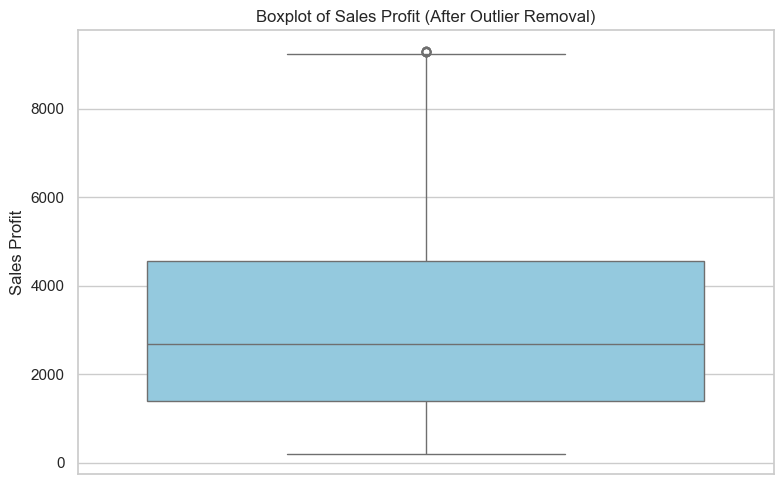

In [27]:
def remove_outliers_iqr(df, column):
    # Drop NaN in the column to avoid invalid calculations
    initial_rows = df.shape[0]
    df = df.dropna(subset=[column])
    dropped_nan = initial_rows - df.shape[0]
    if dropped_nan > 0:
        print(f"  Dropped {dropped_nan} rows with NaN in '{column}' before outlier removal.")

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    num_outliers = outliers.shape[0]

    if num_outliers > 0:
        print(f"Column: '{column}'")
        print(f"  Outliers detected: {num_outliers}")
        print(f"  Value range for outliers: < {lower_bound:.2f} or > {upper_bound:.2f}")
        print(f"  Min outlier value: {outliers[column].min()}")
        print(f"  Max outlier value: {outliers[column].max()}\n")
    else:
        print(f"Column: '{column}' - No outliers detected.\n")

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# BOXPLOT BEFORE OUTLIER REMOVAL
plt.figure(figsize=(12, 5))
df_boxplot_before = df.copy()
sns.boxplot(data=df_boxplot_before[['Quantity', 'Sales Profit']], palette='coolwarm')
plt.title("Boxplot Before Outlier Removal")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

# Apply to selected columns
for col in ['Quantity', 'Sales Profit']:
    print(f"\nProcessing outliers for '{col}'...")
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

print("Outlier removal using IQR completed.")
print(f"Dataset Shape after outlier removal: {df_cleaned.shape}")
print(f"✅Missing values in 'Sales Profit' after outlier removal: {df_cleaned['Sales Profit'].isnull().sum()}")

# Boxplot AFTER outlier removal
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, y='Sales Profit', color='skyblue')
plt.title('Boxplot of Sales Profit (After Outlier Removal)')
plt.ylabel('Sales Profit')
plt.tight_layout()
plt.show()


###  Feature Engineering

In [28]:
df_cleaned['Order Year'] = df_cleaned['Order Date'].dt.year
df_cleaned['Order Month'] = df_cleaned['Order Date'].dt.month
df_cleaned['Order Day'] = df_cleaned['Order Date'].dt.day
df_cleaned['Order Weekday'] = df_cleaned['Order Date'].dt.dayofweek
df_cleaned['Store Age (Days)'] = (df_cleaned['Order Date'] - df_cleaned['Store Open Date']).dt.days
# Handle division by zero in Profit per Item
df_cleaned['Profit per Item'] = np.where(df_cleaned['Quantity'] == 0, 0,
                                         df_cleaned['Sales Profit'] / df_cleaned['Quantity'])

# ADV. FEATURE ENGINEERING
# 1. Label Count Encoding (LCA) for 'City'
city_counts = df_cleaned['City'].value_counts()
df_cleaned['City_LCA'] = df_cleaned['City'].map(city_counts)

# 2. Statistical Polynomial Aggregate (SPA) using derived 'Sales'
df_cleaned['Sales'] = df_cleaned['Price'] * df_cleaned['Quantity']
df_cleaned['Sales_Quantity_SPA'] = df_cleaned['Sales'] * (df_cleaned['Quantity'] ** 2)

# Check for NaN and non-finite values in Sales Profit after feature engineering
print(f"\n✅Missing values in 'Sales Profit' after feature engineering: {df_cleaned['Sales Profit'].isnull().sum()}")
print(f"✅Rows with non-finite 'Sales Profit' (inf or NaN): {(~np.isfinite(df_cleaned['Sales Profit'])).sum()}")
print(f"✅Rows with Quantity == 0: {(df_cleaned['Quantity'] == 0).sum()}")

# Drop rows with NaN or non-finite values in Sales Profit
initial_rows = df_cleaned.shape[0]
df_cleaned = df_cleaned[np.isfinite(df_cleaned['Sales Profit'])]
dropped_rows = initial_rows - df_cleaned.shape[0]
print(f"\nDropped {dropped_rows} rows with NaN or non-finite values in 'Sales Profit'.")



✅Missing values in 'Sales Profit' after feature engineering: 0
✅Rows with non-finite 'Sales Profit' (inf or NaN): 0
✅Rows with Quantity == 0: 0

Dropped 0 rows with NaN or non-finite values in 'Sales Profit'.


### Exploratory Data Analysis (EDA)

#### univariate

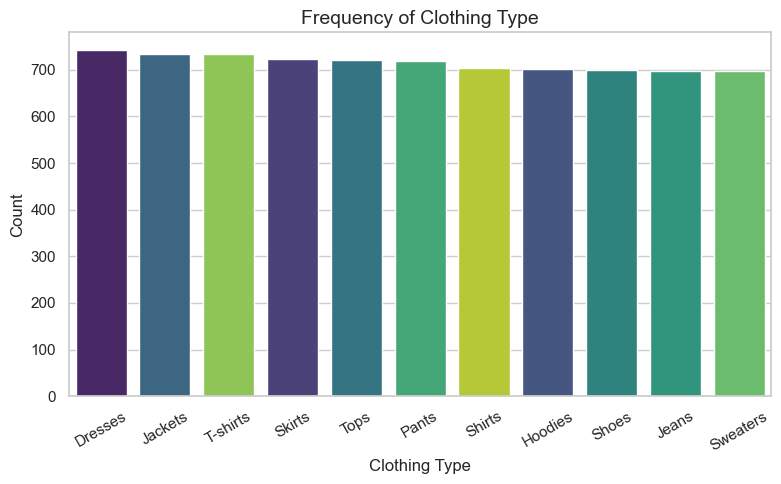

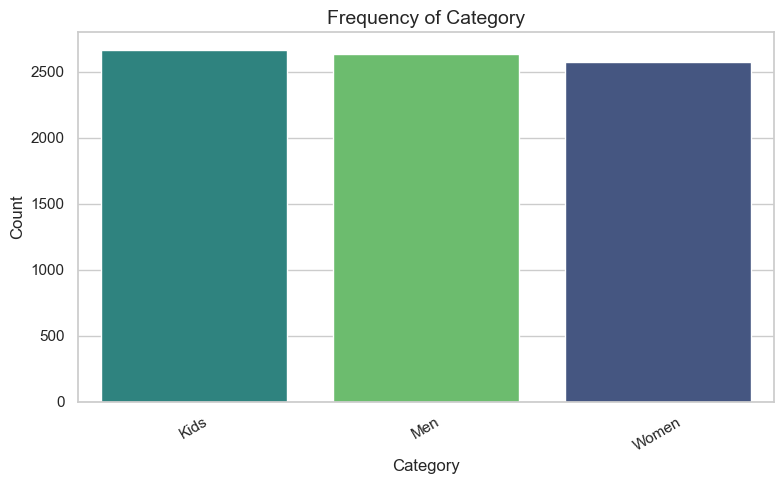

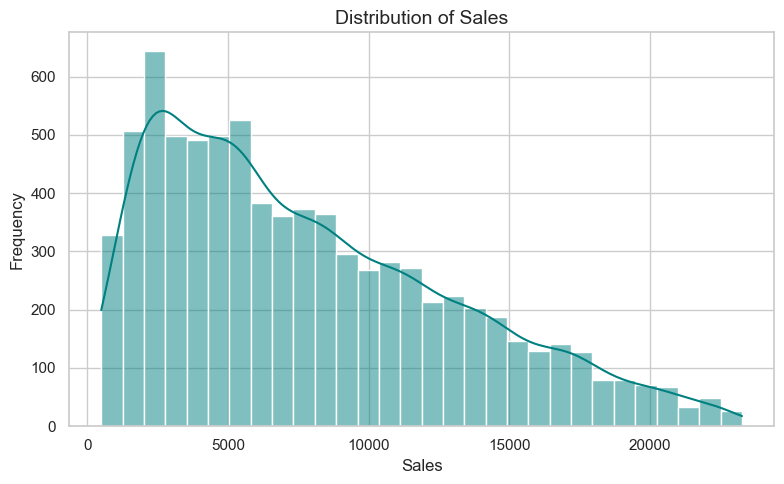

In [29]:
sns.set(style='whitegrid')
selected_cat_cols = ['Clothing Type', 'Category']

for col in selected_cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_cleaned, x=col, hue=col, palette='viridis', order=df_cleaned[col].value_counts().index,
                  legend=False)
    plt.title(f'Frequency of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Histogram of Sales
plt.figure(figsize=(8, 5))
sns.histplot(data=df_cleaned, x='Sales', bins=30, color='teal', kde=True)
plt.title('Distribution of Sales', fontsize=14)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

#### bivariate

✅ Average Sales Profit by City (Descending Order):

             City  Sales Profit
19       Kolhapur   3452.259887
15          Jalna   3426.432323
0            Agra   3363.662703
37          Surat   3304.062366
25         Mysuru   3291.940097
41  Visakhapatnam   3272.743750
12      Hyderabad   3269.247761
31    Pondicherry   3268.347305
7    Chhattisgarh   3263.554404
21        Lucknow   3262.885561
8      Coimbatore   3244.945455
30          Patna   3244.137143
4          Bhopal   3242.555665
16          Jammu   3232.748768
3       Bengaluru   3211.388601
9       Faridabad   3197.426901
35         Satara   3191.541573
13         Indore   3181.632000
6         Chennai   3180.017778
14         Jaipur   3178.523404
2      Aurangabad   3171.631325
1       Ahmedabad   3167.290722
33         Rajkot   3137.782178
20        Kolkata   3135.163810
39       Vadodara   3134.851111
23         Meerut   3111.001105
40       Varanasi   3102.067368
22        Madurai   3085.994118
11       Guwahati   

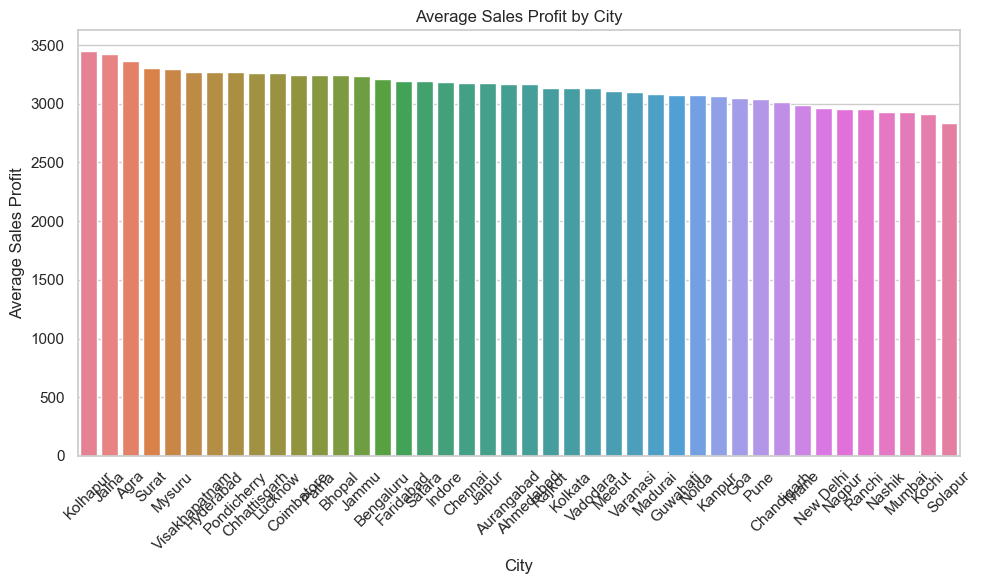

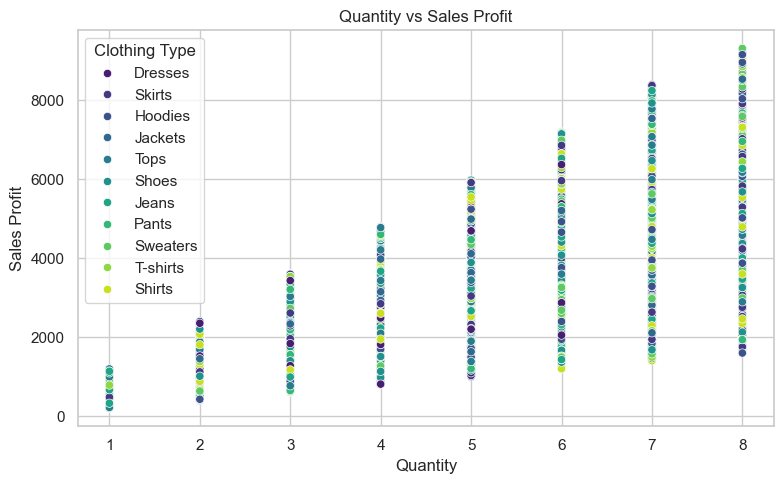

✅ Average Sales Profit by Clothing Type (Sorted by Mean Profit):

Clothing Type
Sweaters    3280.591679
Hoodies     3234.827350
Shirts      3232.759091
Pants       3195.320723
Skirts      3170.694329
Dresses     3130.705249
Jackets     3118.435471
Jeans       3088.558967
T-shirts    3081.884857
Shoes       3051.220029
Tops        3042.633333
Name: Sales Profit, dtype: float64


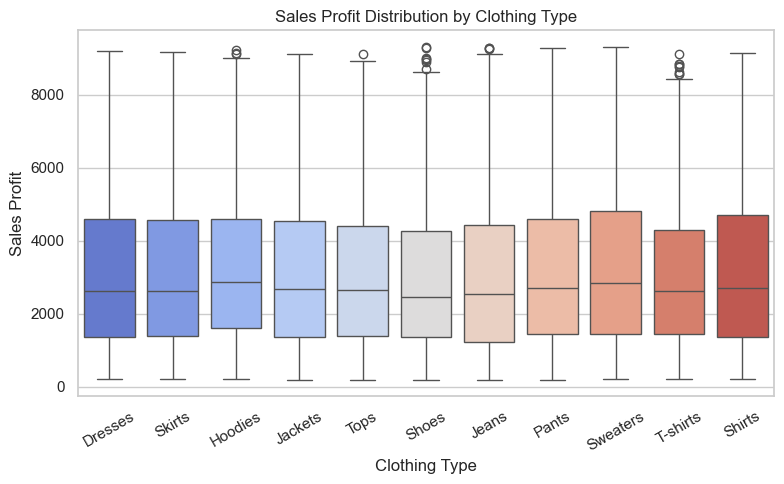

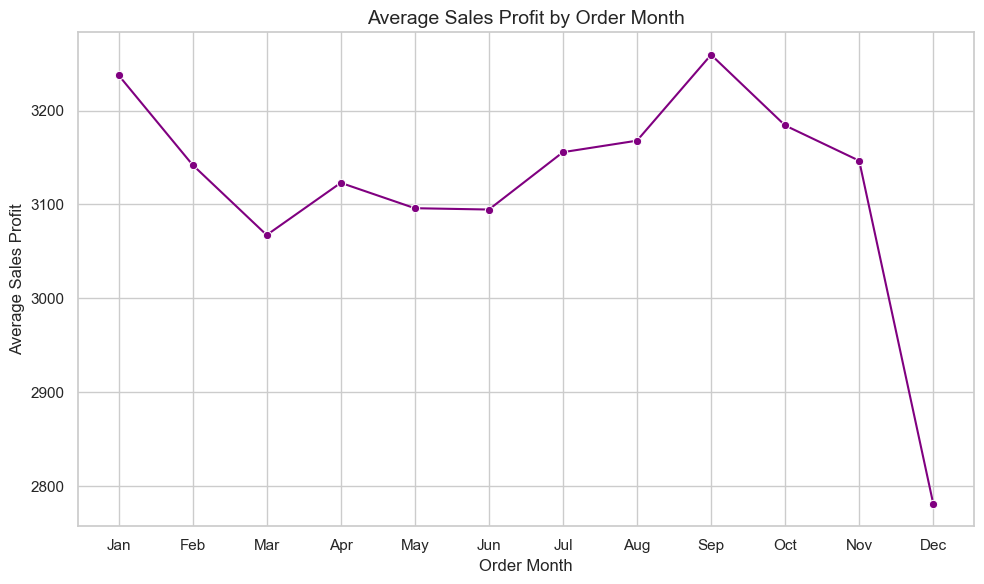

In [9]:
city_profit = df_cleaned.groupby('City')['Sales Profit'].mean().reset_index().sort_values(by='Sales Profit',
                                                                                          ascending=False)
print("✅ Average Sales Profit by City (Descending Order):\n")
print(city_profit)

plt.figure(figsize=(10, 6))
sns.barplot(data=city_profit, x='City', y='Sales Profit', hue='City', legend=False)
plt.title("Average Sales Profit by City")
plt.xlabel("City")
plt.ylabel("Average Sales Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_cleaned, x='Quantity', y='Sales Profit', hue='Clothing Type', palette='viridis')
plt.title("Quantity vs Sales Profit")
plt.xlabel("Quantity")
plt.ylabel("Sales Profit")
plt.tight_layout()
plt.show()

# Group by Clothing Type and calculate mean Sales Profit
boxplot_summary = df_cleaned.groupby('Clothing Type')['Sales Profit'].mean().sort_values(ascending=False)
print("✅ Average Sales Profit by Clothing Type (Sorted by Mean Profit):\n")
print(boxplot_summary)
# Boxplot of Sales Profit by Clothing Type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x='Clothing Type', y='Sales Profit', hue='Clothing Type', palette='coolwarm', legend=False)
plt.title("Sales Profit Distribution by Clothing Type")
plt.xlabel("Clothing Type")
plt.ylabel("Sales Profit")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Sales Profit over Order Month (Seasonal Trends)
monthly_profit = df_cleaned.groupby('Order Month')['Sales Profit'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_profit, x='Order Month', y='Sales Profit', marker='o', color='purple')
plt.title('Average Sales Profit by Order Month', fontsize=14)
plt.xlabel('Order Month', fontsize=12)
plt.ylabel('Average Sales Profit', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

#### multivariate

✅ Total Sales Profit by Category in Each City (Descending):
         City Category  Sales Profit
         Agra    Women      224585.6
         Agra     Kids      204301.6
         Agra      Men      193390.4
    Ahmedabad     Kids      219043.6
    Ahmedabad    Women      215340.8
    Ahmedabad      Men      180070.0
   Aurangabad    Women      180926.4
   Aurangabad     Kids      177451.2
   Aurangabad      Men      168113.2
    Bengaluru    Women      227189.6
    Bengaluru     Kids      203842.8
    Bengaluru      Men      188765.6
       Bhopal      Men      248808.0
       Bhopal    Women      208685.6
       Bhopal     Kids      200745.2
   Chandigarh    Women      225599.2
   Chandigarh      Men      189899.2
   Chandigarh     Kids      157363.2
      Chennai    Women      193496.4
      Chennai     Kids      189729.6
      Chennai      Men      189177.2
 Chhattisgarh     Kids      236352.4
 Chhattisgarh    Women      204117.2
 Chhattisgarh      Men      189396.4
   Coimbatore  

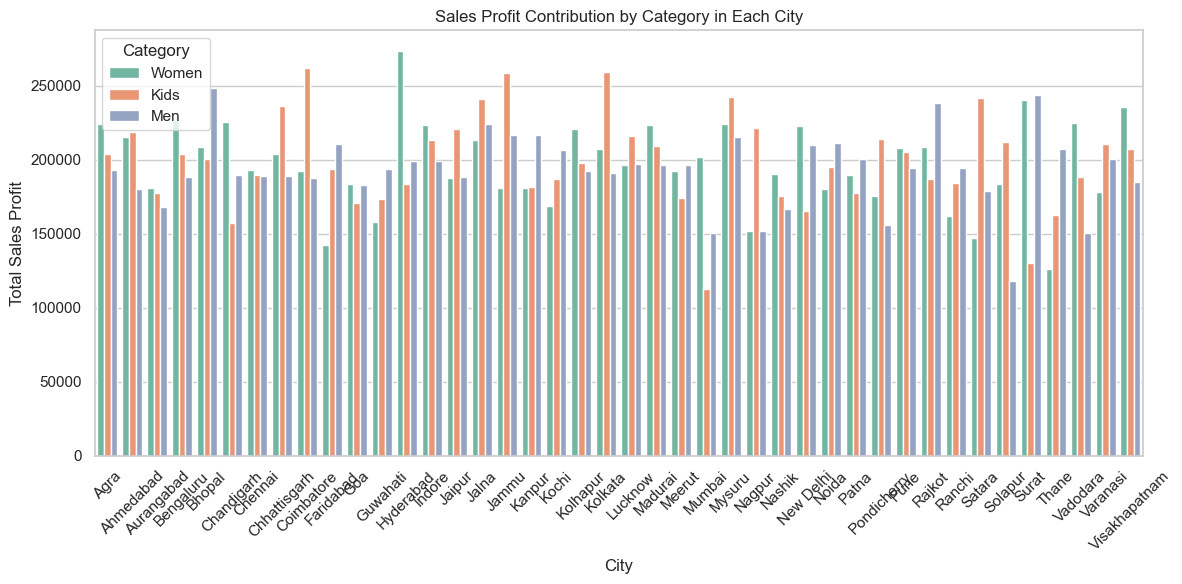


✅ Top 3 Clothing Types by Category in Each City:
         City Category Clothing Type  Sales Profit
         Agra     Kids          Tops       33336.8
         Agra     Kids        Skirts       25878.8
         Agra     Kids        Shirts       24131.6
         Agra      Men      Sweaters       24636.0
         Agra      Men       Jackets       23563.2
         Agra      Men        Skirts       22780.0
         Agra    Women         Pants       33531.2
         Agra    Women       Dresses       30414.8
         Agra    Women       Hoodies       29519.6
    Ahmedabad     Kids         Shoes       28290.8
    Ahmedabad     Kids         Pants       27889.2
    Ahmedabad     Kids         Jeans       26580.0
    Ahmedabad      Men       Jackets       25194.0
    Ahmedabad      Men      Sweaters       22856.4
    Ahmedabad      Men         Jeans       22222.4
    Ahmedabad    Women       Dresses       34156.4
    Ahmedabad    Women         Pants       28820.0
    Ahmedabad    Women          

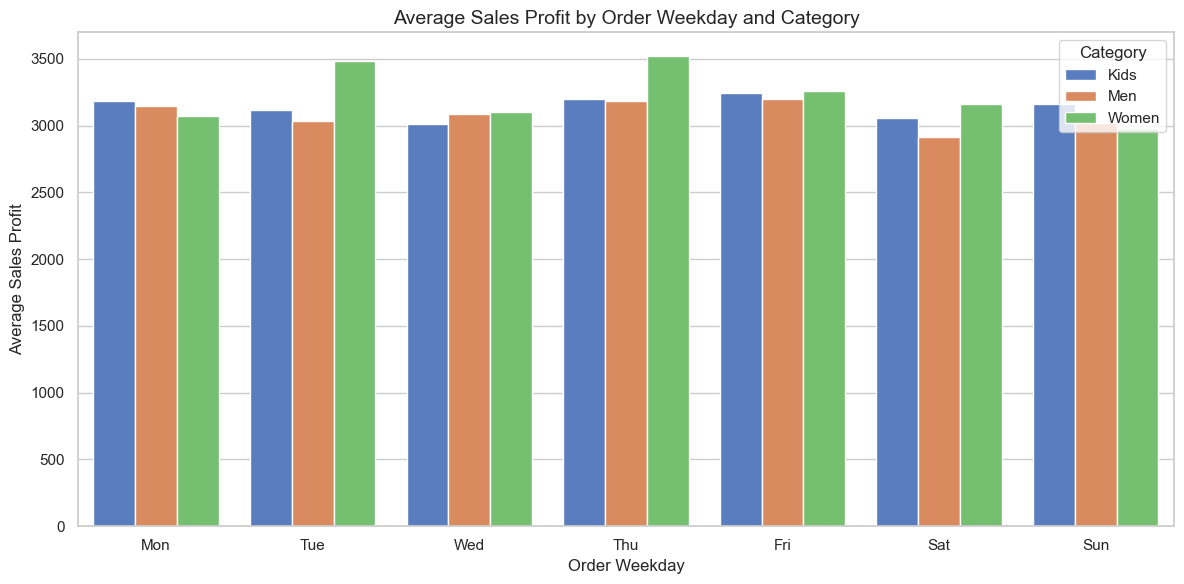

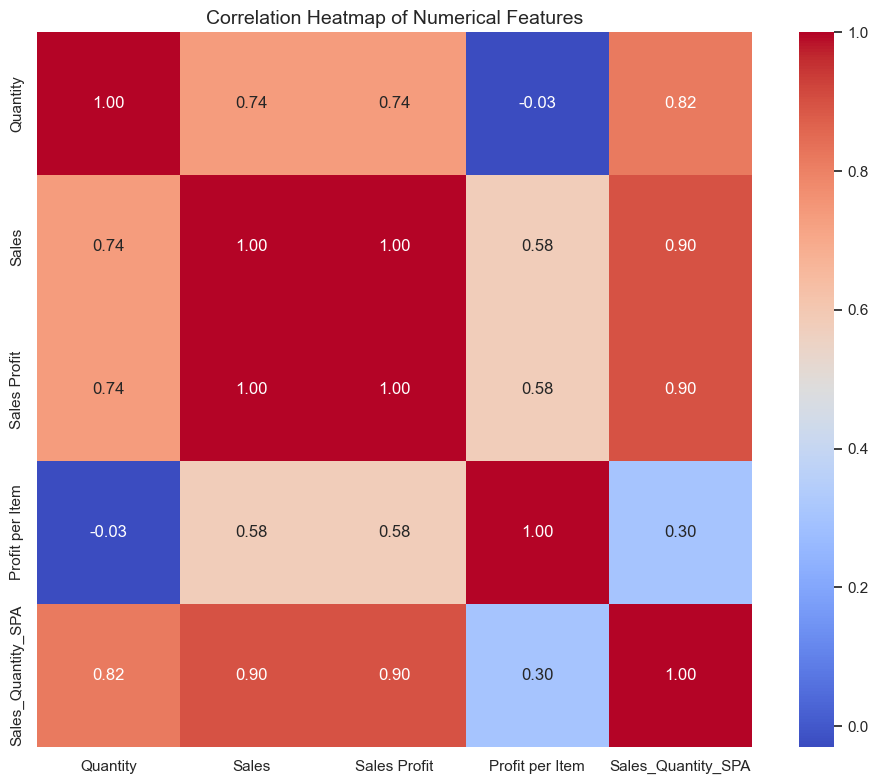

In [10]:
city_category_profit = df_cleaned.groupby(['City', 'Category'])['Sales Profit'].sum().reset_index()
city_category_profit_sorted = city_category_profit.sort_values(by=['City', 'Sales Profit'], ascending=[True, False])
print("✅ Total Sales Profit by Category in Each City (Descending):")
print(city_category_profit_sorted.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=city_category_profit_sorted, x='City', y='Sales Profit', hue='Category', palette='Set2')
plt.title("Sales Profit Contribution by Category in Each City")
plt.xlabel("City")
plt.ylabel("Total Sales Profit")
plt.legend(title="Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_clothing_types = df_cleaned.groupby(['City', 'Category', 'Clothing Type'])[
    'Sales Profit'].sum().reset_index().sort_values(by=['City', 'Category', 'Sales Profit'],
                                                    ascending=[True, True, False])
top3_clothing = top_clothing_types.groupby(['City', 'Category']).head(3).reset_index(drop=True)

print("\n✅ Top 3 Clothing Types by Category in Each City:")
print(top3_clothing.to_string(index=False))

#Sales Profit by Order Weekday and Category
weekday_category_profit = df_cleaned.groupby(['Order Weekday', 'Category'])['Sales Profit'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=weekday_category_profit, x='Order Weekday', y='Sales Profit', hue='Category', palette='muted')
plt.title('Average Sales Profit by Order Weekday and Category', fontsize=14)
plt.xlabel('Order Weekday', fontsize=12)
plt.ylabel('Average Sales Profit', fontsize=12)
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.legend(title='Category')
plt.tight_layout()
plt.show()

# Correlation Heatmap of Numerical Features
numerical_cols = ['Quantity', 'Sales', 'Sales Profit', 'Profit per Item', 'Sales_Quantity_SPA']
corr_matrix = df_cleaned[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### Reset indices to avoid misalignment

In [36]:
df_cleaned = df_cleaned.reset_index(drop=True) 

###  Machine Learning Model Development

In [37]:
# Update feature set to include engineered features
X = df_cleaned[['Quantity', 'City', 'Clothing Type', 'Category', 'Order Month', 'Order Weekday',
                'Store Age (Days)', 'Profit per Item', 'City_LCA', 'Sales_Quantity_SPA']]
y = df_cleaned['Sales Profit']

# Reset indices for X and y
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Check index alignment
print("\n✅Index alignment check: X and y indices match?", X.index.equals(y.index))

# Apply target encoding to 'City' to reduce dimensionality
target_encoder = TargetEncoder(cols=['City'])
X_encoded = X.copy()
X_encoded['City_encoded'] = target_encoder.fit_transform(X[['City']], y)
X_encoded = X_encoded.drop('City', axis=1)

# One-hot encode categorical variables and scale numerical features
categorical_cols = ['Clothing Type', 'Category']
numerical_cols = ['Quantity', 'Order Month', 'Order Weekday', 'Store Age (Days)',
                  'Profit per Item', 'City_LCA', 'Sales_Quantity_SPA', 'City_encoded']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ])
X_processed_array = preprocessor.fit_transform(X_encoded)

# Convert to DataFrame to retain feature names
feature_names = (preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() +
                 numerical_cols)
X_processed = pd.DataFrame(X_processed_array, columns=feature_names)

# Reset indices for X_processed
X_processed = X_processed.reset_index(drop=True)

# Check shapes and index alignment
print(f"\n✅X_processed shape: {X_processed.shape}")
print(f"✅y shape: {y.shape}")
print("✅Index alignment check: X_processed and y indices match?", X_processed.index.equals(y.index))

# Check for NaN in y before train-test split
print("\n✅Missing values in y (Sales Profit) before train-test split:", y.isnull().sum())
print(f"✅Rows with non-finite y (inf or NaN): {(~np.isfinite(y)).sum()}")

# Final drop of NaN in y
initial_y_len = len(y)
y = y.dropna()
dropped_y = initial_y_len - len(y)
print(f"✅Dropped {dropped_y} rows with NaN in y (Sales Profit).")
# Drop corresponding rows in X_processed
X_processed = X_processed.loc[y.index].reset_index(drop=True)
y = y.reset_index(drop=True)

# Train-test split
X_train_s, X_test_s, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Verify no NaN in y_train and y_test
print("\n✅Missing values in y_train:", y_train.isnull().sum())
print("✅Missing values in y_test:", y_test.isnull().sum())
print(f"✅Rows with non-finite y_train: {(~np.isfinite(y_train)).sum()}")
print(f"✅Rows with non-finite y_test: {(~np.isfinite(y_test)).sum()}")



✅Index alignment check: X and y indices match? True

✅X_processed shape: (7870, 20)
✅y shape: (7870,)
✅Index alignment check: X_processed and y indices match? True

✅Missing values in y (Sales Profit) before train-test split: 0
✅Rows with non-finite y (inf or NaN): 0
✅Dropped 0 rows with NaN in y (Sales Profit).

✅Missing values in y_train: 0
✅Missing values in y_test: 0
✅Rows with non-finite y_train: 0
✅Rows with non-finite y_test: 0


### Feature Selection using random forest

In [38]:
rf_for_selection = RandomForestRegressor(random_state=42, verbose=0)
rf_for_selection.fit(X_train_s, y_train)
importances_rf = rf_for_selection.feature_importances_
feature_importance_rf = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# Select features contributing to 80% of cumulative importance (using Random Forest)
feature_importance_rf['Cumulative Importance'] = feature_importance_rf['Importance'].cumsum()
total_importance = feature_importance_rf['Importance'].sum()
threshold = 0.8 * total_importance
selected_features = feature_importance_rf[feature_importance_rf['Cumulative Importance'] <= threshold][
    'Feature'].tolist()

# Ensure at least one feature is selected
if not selected_features:
    selected_features = feature_importance_rf.head(1)['Feature'].tolist()

# Select subset of features as DataFrame
X_train_s_selected = X_train_s[selected_features]
X_test_s_selected = X_test_s[selected_features]

# Reset indices for X_train_s_selected and X_test_s_selected
X_train_s_selected = X_train_s_selected.reset_index(drop=True)
X_test_s_selected = X_test_s_selected.reset_index(drop=True)

### Model Training and Evaluation

#### Linear regression

In [39]:
lr_for_importance = LinearRegression()
lr_for_importance.fit(X_train_s, y_train)
lr_importances = np.abs(lr_for_importance.coef_) / np.sum(np.abs(lr_for_importance.coef_))
feature_importance_lr = pd.DataFrame({'Feature': feature_names, 'Importance': lr_importances})


####  XGBoost

In [40]:
xgb_for_importance = XGBRegressor(random_state=42, verbosity=0)
xgb_for_importance.fit(X_train_s, y_train)
xgb_importances = xgb_for_importance.feature_importances_
feature_importance_xgb = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importances})

#### LightGBM

In [41]:
lgbm_for_importance = LGBMRegressor(random_state=42, verbose=-1)
lgbm_for_importance.fit(X_train_s, y_train)
lgbm_importances = lgbm_for_importance.feature_importances_ / np.sum(lgbm_for_importance.feature_importances_)
feature_importance_lgbm = pd.DataFrame({'Feature': feature_names, 'Importance': lgbm_importances})

#### CatBoost

In [42]:
catboost_for_importance = CatBoostRegressor(random_state=42, verbose=0)
catboost_for_importance.fit(X_train_s, y_train)
catboost_importances = catboost_for_importance.feature_importances_ / np.sum(
    catboost_for_importance.feature_importances_)
feature_importance_catboost = pd.DataFrame({'Feature': feature_names, 'Importance': catboost_importances})

#### Combine feature importances into a single DataFrame

In [43]:
feature_importance_combined = feature_importance_rf[['Feature', 'Importance']].rename(
    columns={'Importance': 'Random Forest'})
feature_importance_combined['Linear Regression'] = feature_importance_lr['Importance']
feature_importance_combined['XGBoost'] = feature_importance_xgb['Importance']
feature_importance_combined['LightGBM'] = feature_importance_lgbm['Importance']
feature_importance_combined['CatBoost'] = feature_importance_catboost['Importance']

# Display feature importance for all models
print("\n✅ Feature Importance from All Models:")
print(feature_importance_combined.sort_values(by='Random Forest', ascending=False))

print(f"\n✅ Selected Features (Top 80% Cumulative Importance, based on Random Forest): {selected_features}")

# Initialize models with suppressed verbosity
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, verbose=0),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

# Hyperparameter grids (exclude Linear Regression)
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    'LightGBM': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [31, 50]
    },
    'CatBoost': {
        'iterations': [100, 200],
        'learning_rate': [0.05, 0.1],
        'depth': [4, 6]
    }
}

# Store results
best_models = {}
r2_scores = {}
cv_scores = {}
predictions = {}

# Evaluate and tune models
for name, model in models.items():
    if name in param_grids:
        grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='r2', n_jobs=-1, verbose=0)
        grid_search.fit(X_train_s_selected, y_train)
        best_models[name] = grid_search.best_estimator_
        y_pred = grid_search.best_estimator_.predict(X_test_s_selected)
    else:
        # Linear Regression (no tuning)
        model.fit(X_train_s_selected, y_train)
        best_models[name] = model
        y_pred = model.predict(X_test_s_selected)

    # Create comparison DataFrame
    comparison = pd.DataFrame(X_test_s_selected, columns=selected_features)
    comparison = comparison.copy()
    comparison["Actual Profit"] = y_test.reset_index(drop=True)
    comparison[f"Predicted ({name})"] = y_pred

    # Store predictions
    r2_scores[name] = r2_score(y_test, y_pred)
    cv_scores[name] = cross_val_score(best_models[name], X_train_s_selected, y_train, cv=5, scoring='r2')
    predictions[name] = y_pred

    # Print results in the requested format
    print(f"\n{name} R² Score: {r2_scores[name]}")
    print(f"\n📈 {name}: Actual vs Predicted")
    print(comparison.head(10))
    print(f"{name} Cross-Validation R² scores: {cv_scores[name]}")
    print(f"Average R² ({name}): {cv_scores[name].mean()}")

# Compare models
print("\n✅ Model Comparison:")
comparison_table = pd.DataFrame({
    'Model': r2_scores.keys(),
    'Test R² Score': r2_scores.values(),
    'Average CV R² Score': [cv_scores[name].mean() for name in r2_scores.keys()]
})
comparison_table = comparison_table.sort_values(by='Average CV R² Score', ascending=False)
print(comparison_table)

# Select the best model based on average cross-validation R²
best_model_name = max(cv_scores, key=lambda k: cv_scores[k].mean())
best_model = best_models[best_model_name]
print(f"\n✅ Best Model Based on Average Cross-Validation R² Score: {best_model_name}")
print(f"Average R² Score: {cv_scores[best_model_name].mean():.4f}")


✅ Feature Importance from All Models:
                   Feature  Random Forest  Linear Regression   XGBoost  \
18      Sales_Quantity_SPA   7.899357e-01           0.310365  0.847652   
16         Profit per Item   2.100335e-01           0.329976  0.151990   
12                Quantity   1.669500e-05           0.285058  0.000104   
15        Store Age (Days)   2.652642e-06           0.001918  0.000023   
19            City_encoded   2.518846e-06           0.004007  0.000022   
17                City_LCA   2.285420e-06           0.000522  0.000019   
13             Order Month   1.900899e-06           0.003042  0.000016   
14           Order Weekday   1.708680e-06           0.002327  0.000015   
11          Category_Women   5.204570e-07           0.004220  0.000014   
10            Category_Men   4.891282e-07           0.000303  0.000013   
0    Clothing Type_Hoodies   2.338424e-07           0.015565  0.000013   
3      Clothing Type_Pants   2.322836e-07           0.012506  0.000011   

### Model Diagnostics and Learning Curves


✅ Generating Learning Curves for ML Models


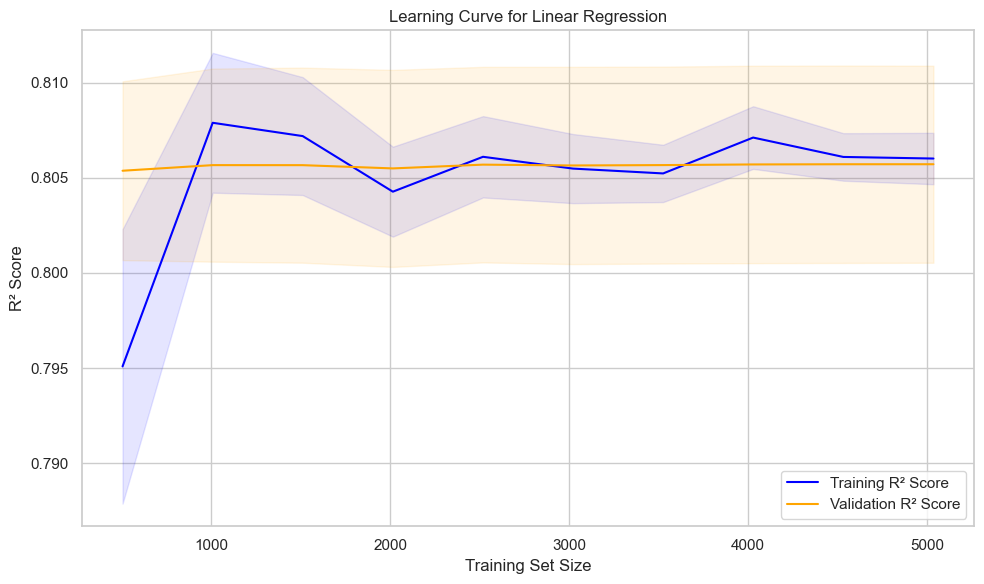

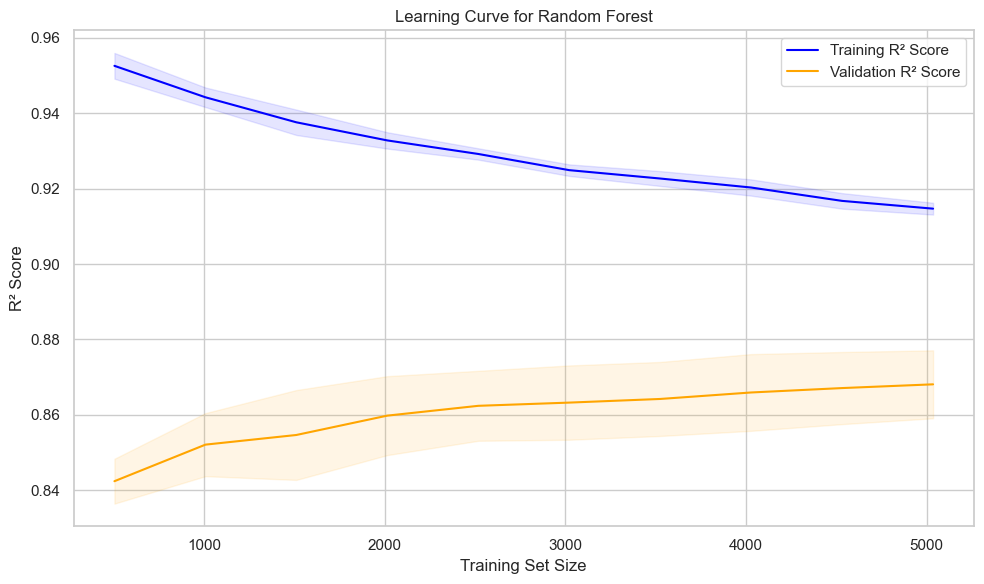

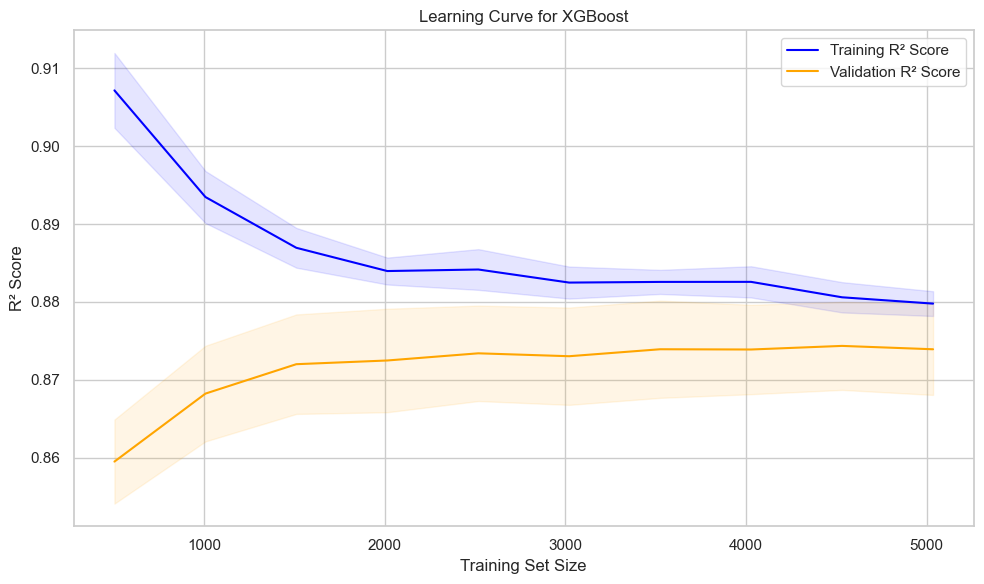

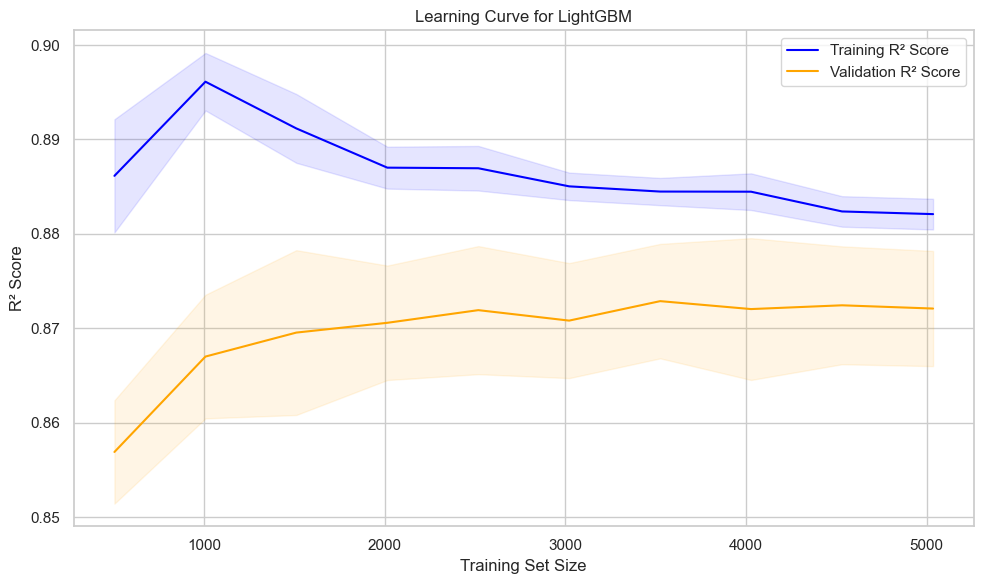

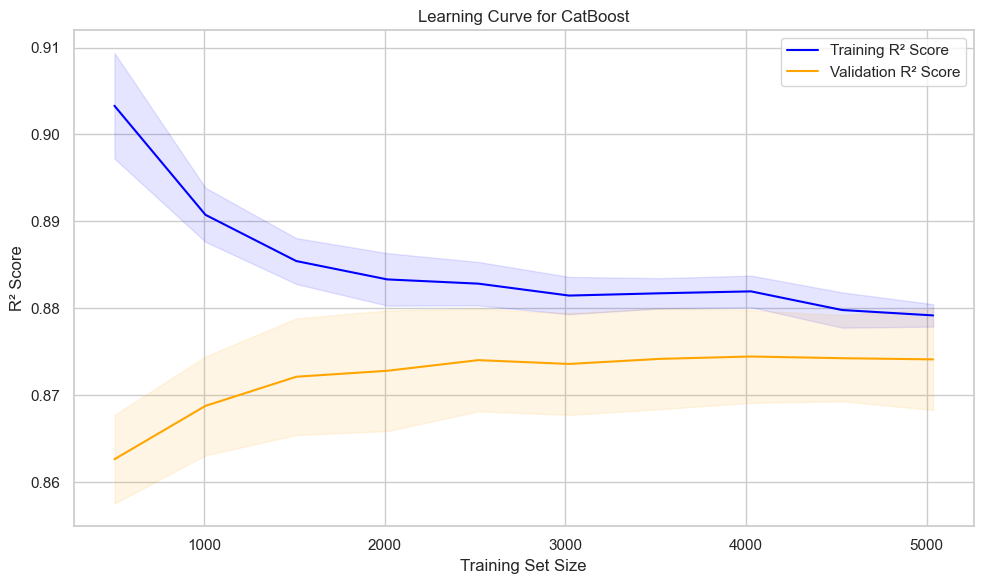

In [44]:
print("\n✅ Generating Learning Curves for ML Models")

# Function to plot learning curves
def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='r2', verbose=0
    )

    # Compute mean and standard deviation
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)

    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label='Training R² Score', color='blue')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1,
                     color='blue')
    plt.plot(train_sizes, val_scores_mean, label='Validation R² Score', color='orange')
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1,
                     color='orange')

    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('R² Score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Generate learning curves for each model
for name, model in best_models.items():
    plot_learning_curve(
        estimator=model,
        title=f"Learning Curve for {name}",
        X=X_train_s_selected,
        y=y_train,
        cv=5
    )

### Prediction and Output

In [20]:
# Predict using the best model
new_input = pd.DataFrame([{
    'Quantity': 12,
    'City': 'Mumbai',
    'Clothing Type': 'Men',
    'Category': 'Jeans',
    'Order Month': 4,
    'Order Weekday': 3,  # Thursday
    'Store Age (Days)': 365,  # Example value
    'Profit per Item': 100,  # Example value
    'City_LCA': city_counts.get('Mumbai', city_counts.mean()),  # Use mean if city not found
    'Sales_Quantity_SPA': 12 * 500 * (12 ** 2)  # Example: Price=500
}])

# Encode and scale new input
new_input_encoded = new_input.copy()
new_input_encoded['City_encoded'] = target_encoder.transform(new_input[['City']])
new_input_encoded = new_input_encoded.drop('City', axis=1)
new_input_processed_array = preprocessor.transform(new_input_encoded)
new_input_processed = pd.DataFrame(new_input_processed_array, columns=feature_names)
new_input_selected = new_input_processed[selected_features]
predicted_profit = best_model.predict(new_input_selected)
print(f"\n🔮 Predicted Sales Profit using {best_model_name}: ₹{predicted_profit[0]:.2f}")

# Save the final processed dataset with a new name
final_output_path = "C:\\Users\\Administrator\\Desktop\\PDS\\Project\\final_dataset_end.csv"
df_cleaned.to_csv(final_output_path, index=False)
print(f"\n✅ Final dataset saved at: {final_output_path}")


🔮 Predicted Sales Profit using CatBoost: ₹6242.53

✅ Final dataset saved at: C:\Users\Administrator\Desktop\PDS\Project\final_dataset_end.csv
